In [1]:
import pandas as pd

In [2]:
import unicodedata
import re
from unidecode import unidecode

def normalize_name(name):

    name = name.lower()

    name = unidecode(name)

    name = re.sub(r'[^\w\s]', '', name) 
    name = re.sub(r'\s+', ' ', name).strip()  
    
    replacements = {
        'jr': '', 'sr': '', 'dr': '', 'lic': '', 'ing': '', 
        'mtro': '', 'phd': '', 'c': '', 's a': '', 's.a.': ''
    }
    
    for k, v in replacements.items():
        name = name.replace(k, v)
    
    return name








In [3]:
df = pd.read_json('data/openalex_authors_complete.json')

In [3]:
df1 = pd.read_json('data/openalex_data.json')

In [4]:
df=df.T
df.head()

,id,orcid,display_name,display_name_alternatives,works_count,cited_by_count,summary_stats,ids,affiliations,last_known_institutions,topics,topic_share,x_concepts,counts_by_year,works_api_url,updated_date,created_date
A5001442172,https://openalex.org/A5001442172,https://orcid.org/0000-0001-5336-7744,Roxana Sobrino Triana,"[Roxana Sobrino, Roxana Sobrino Triana]",14,20,"{'2yr_mean_citedness': 0.0, 'h_index': 3, 'i10...",{'openalex': 'https://openalex.org/A5001442172...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I4432739', 'ror'...","[{'id': 'https://openalex.org/T12341', 'displa...","[{'id': 'https://openalex.org/T12341', 'displa...","[{'id': 'https://openalex.org/C142362112', 'wi...","[{'year': 2025, 'works_count': 1, 'cited_by_co...",https://api.openalex.org/works?filter=author.i...,2025-07-05T02:34:00.814341,2023-07-21
A5086708085,https://openalex.org/A5086708085,https://orcid.org/0000-0001-5824-6415,David E. Williams,"[D. E. Williams, David Williams, D. Williams, ...",376,17232,"{'2yr_mean_citedness': 1.941176470588235, 'h_i...",{'openalex': 'https://openalex.org/A5086708085...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I141945490', 'ro...","[{'id': 'https://openalex.org/T10252', 'displa...","[{'id': 'https://openalex.org/T11340', 'displa...","[{'id': 'https://openalex.org/C86803240', 'wik...","[{'year': 2025, 'works_count': 1, 'cited_by_co...",https://api.openalex.org/works?filter=author.i...,2025-07-08T23:16:15.725665,2023-07-21
A5017904400,https://openalex.org/A5017904400,https://orcid.org/0000-0003-0331-1413,Simoni Campos Dias,"[Sarah Dias, Simoni C. Dias, Simoni Campos Dia...",103,3083,"{'2yr_mean_citedness': 3.0, 'h_index': 29, 'i1...",{'openalex': 'https://openalex.org/A5017904400...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I24871856', 'ror...","[{'id': 'https://openalex.org/T11103', 'displa...","[{'id': 'https://openalex.org/T11103', 'displa...","[{'id': 'https://openalex.org/C86803240', 'wik...","[{'year': 2025, 'works_count': 3, 'cited_by_co...",https://api.openalex.org/works?filter=author.i...,2025-07-08T20:14:32.664231,2023-07-21
A5067766228,https://openalex.org/A5067766228,https://orcid.org/0000-0001-7029-6407,Uwe Kappelmeyer,"[Uwe Kappelmeyer, U. Kappelmeyer]",52,2977,"{'2yr_mean_citedness': 8.5, 'h_index': 21, 'i1...",{'openalex': 'https://openalex.org/A5067766228...,[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I137479271', 'ro...","[{'id': 'https://openalex.org/T11624', 'displa...","[{'id': 'https://openalex.org/T11624', 'displa...","[{'id': 'https://openalex.org/C86803240', 'wik...","[{'year': 2025, 'works_count': 0, 'cited_by_co...",https://api.openalex.org/works?filter=author.i...,2025-07-12T03:13:18.376503,2023-07-21
A5061854858,https://openalex.org/A5061854858,None,Gabriela García-Hernández,[Gabriela García‐Hernández],1,0,"{'2yr_mean_citedness': 0.0, 'h_index': 0, 'i10...",{'openalex': 'https://openalex.org/A5061854858'},[{'institution': {'id': 'https://openalex.org/...,"[{'id': 'https://openalex.org/I4210142152', 'r...","[{'id': 'https://openalex.org/T13255', 'displa...","[{'id': 'https://openalex.org/T13550', 'displa...","[{'id': 'https://openalex.org/C15708023', 'wik...","[{'year': 2021, 'works_count': 1, 'cited_by_co...",https://api.openalex.org/works?filter=author.i...,2025-05-16T10:01:03.952815,2023-07-21


In [5]:
df = df.drop(columns=['id','orcid','works_count','cited_by_count','summary_stats','ids','affiliations','last_known_institutions','topics','topic_share','x_concepts','counts_by_year','works_api_url','updated_date','created_date'])

In [6]:
df.index = list(range(1,len(df)+1))

In [7]:
df.display_name.value_counts()

display_name
Jing Li                              7
F Dionisio                           7
R Lalana                             6
Carlos Rodríguez                     5
Deleted Author ID                    5
                                    ..
Rodrigo Soares Caldeira              1
Rodolfo Gómez Ponce de León          1
Victoria Del Carmen Collazo Frías    1
Pedro Sánchez                        1
Uwe Kappelmeyer                      1
Name: count, Length: 29683, dtype: int64

In [8]:
df=df.drop_duplicates(subset=['display_name'])

In [9]:
df.display_name.value_counts()

display_name
Roxana Sobrino Triana         1
David E. Williams             1
Simoni Campos Dias            1
Uwe Kappelmeyer               1
Gabriela García-Hernández     1
                             ..
Taimy Chávez Rodríguez        1
MI Rey                        1
Ó. Juan Vidal                 1
Isabel Fernández              1
Magaly Hernandez Sotolongo    1
Name: count, Length: 29683, dtype: int64

In [10]:
df['display_name_alternatives'] = df['display_name_alternatives'].map(set)

In [11]:
df['display_name']=df['display_name'].apply(normalize_name)

In [12]:
df

,display_name,display_name_alternatives
1,roxana sobrino triana,"{Roxana Sobrino, Roxana Sobrino Triana}"
2,david e williams,"{D. E. Williams, D.E Williams, D. Williams, Da..."
3,simoni ampos dias,"{Sarah Dias, Simoni Campos Dias, Simoni Dias, ..."
4,uwe kappelmeyer,"{Uwe Kappelmeyer, U. Kappelmeyer}"
5,gabriela gariahernandez,{Gabriela García‐Hernández}
...,...,...
30217,taimy havez roiguez,{Taimy Chávez Rodríguez}
30218,mi rey,"{M Basterrechea Rey, M. Rey, MI Rey}"
30219,o juan vidal,"{Olga Vidal, Ó. Juan Vidal}"
30220,isabel fernandez,"{Q.I. Fernández, I. Fernández, Isabel Fernande..."


In [13]:
df_new={}
for _, i in df.iterrows():
    a=set()
    for j in i['display_name_alternatives']:
        n= normalize_name(j)
        a.add(n)
    df_new[i['display_name']]=a

In [14]:
v= df_new.values()
dd = max(v,key=len)
len(dd)

84

In [15]:
df_end= {}
for i,j in df_new.items():
    a=list(j.copy())
    df_end[i]=a

In [48]:
import numpy as np
import random 
def create_training_data(author_variations):
    positive_pairs = []
    negative_pairs = []
    
    for canonical, variations in author_variations.items():
        if not variations:
            continue
        if random.uniform(0,1)>0.85:
            continue
        pa = np.random.choice(variations) 
        
        positive_pairs.append((canonical, pa, 1))
    all_canonicals = list(author_variations.keys())
    for i in range(len(all_canonicals)):
        try:
            if i+1 >= len(all_canonicals):
                continue
            j = random.randint(i+1,len(all_canonicals))
            if random.uniform(0,1)>0.70:
                continue
            author1 = np.random.choice([all_canonicals[i]] + author_variations[all_canonicals[i]])
            author2 = np.random.choice([all_canonicals[j]] + author_variations[all_canonicals[j]])
            negative_pairs.append((author1, author2, 0))
        except:
            pass
    #min_samples = min(len(positive_pairs), len(negative_pairs))
    balanced_data = positive_pairs + negative_pairs
    #np.random.shuffle(balanced_data)
    
    df = pd.DataFrame(balanced_data, columns=['nombre1', 'nombre2', 'etiqueta'])
    return df

training_data = create_training_data(df_end)
print(f"Total muestras: {len(training_data)} (Positivas: {sum(training_data['etiqueta'])}, Negativas: {len(training_data)-sum(training_data['etiqueta'])})")

Total muestras: 45233 (Positivas: 24792, Negativas: 20441)


In [50]:
training_data

,nombre1,nombre2,etiqueta
0,roxana sobrino triana,roxana sobrino triana,1
1,david e williams,david e williams,1
2,simoni ampos dias,simoni dias,1
3,uwe kappelmeyer,uwe kappelmeyer,1
4,gabriela gariahernandez,gabriela gariahernandez,1
...,...,...,...
45228,maria del armen baria,m d blano,0
45229,m dolores blano,o juan vidal,0
45230,taimy havez roiguez,o juan vidal,0
45231,o juan vidal,isabel fernandez,0


In [4]:
from jellyfish import jaro_winkler_similarity, levenshtein_distance, soundex, metaphone


def advanced_features(name1, name2):
    n1 = normalize_name(name1)
    n2 = normalize_name(name2)
    
    tokens1 = n1.split()
    tokens2 = n2.split()
    
    features = {
        'jaro_winkler': jaro_winkler_similarity(n1, n2),
        'levenshtein': levenshtein_distance(n1, n2),
        'length_diff': abs(len(n1) - len(n2)),
        'length_ratio': min(len(n1), len(n2)) / max(len(n1), len(n2), 1),
        'same_soundex': int(soundex(n1) == soundex(n2)),
        'same_metaphone': int(metaphone(n1) == metaphone(n2)),
    }
    
    common_tokens = set(tokens1) & set(tokens2)
    features.update({
        'common_token_count': len(common_tokens),
        'token_ratio': len(common_tokens) / max(len(set(tokens1 + tokens2)), 1),
        'token_jaccard': len(common_tokens) / len(set(tokens1 + tokens2)) if tokens1 or tokens2 else 0,
        'first_token_match': int(tokens1[0] == tokens2[0]) if tokens1 and tokens2 else 0,
        'last_token_match': int(tokens1[-1] == tokens2[-1]) if tokens1 and tokens2 else 0,
    })
    

    initials1 = ''.join([t[0] for t in tokens1 if t])
    initials2 = ''.join([t[0] for t in tokens2 if t])
    features.update({
        'initials_match': int(initials1 == initials2),
        'initials_jaro': jaro_winkler_similarity(initials1, initials2),
    })
    features['inverted_name'] = int(
        " ".join(tokens1[::-1])==" ".join(tokens2[::-1])
    )
    
    return features

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.metrics import classification_report, make_scorer, f1_score


def prepare_data(df):
    X = []
    for _, row in df.iterrows():
        features = advanced_features(row['nombre1'], row['nombre2'])
        X.append(features)
    
    feature_df = pd.DataFrame(X)
    return feature_df, df['etiqueta']


X, y = prepare_data(training_data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


,jaro_winkler,levenshtein,length_diff,length_ratio,same_soundex,same_metaphone,common_token_count,token_ratio,token_jaccard,first_token_match,last_token_match,initials_match,initials_jaro,inverted_name
0,1.000000,0,0,1.000000,1,1,3,1.000000,1.000000,1,1,1,1.000000,1
1,1.000000,0,0,1.000000,1,1,3,1.000000,1.000000,1,1,1,1.000000,1
2,0.893048,6,6,0.647059,0,0,2,0.666667,0.666667,1,1,0,0.611111,0
3,1.000000,0,0,1.000000,1,1,2,1.000000,1.000000,1,1,1,1.000000,1
4,1.000000,0,0,1.000000,1,1,2,1.000000,1.000000,1,1,1,1.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45228,0.608466,16,12,0.428571,0,0,0,0.000000,0.000000,0,0,0,0.933333,0
45229,0.450000,13,3,0.800000,0,0,0,0.000000,0.000000,0,0,0,0.000000,0
45230,0.494152,16,7,0.631579,0,0,0,0.000000,0.000000,0,0,0,0.000000,0
45231,0.513889,14,4,0.750000,0,0,0,0.000000,0.000000,0,0,0,0.000000,0


In [54]:

preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), ['levenshtein', 'length_diff']),
    ('minmax', MinMaxScaler(), ['jaro_winkler', 'length_ratio', 'token_ratio', 'token_jaccard'])
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])


param_grid = {
    'classifier': [RandomForestClassifier(), GradientBoostingClassifier()],
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5],
}


grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring=make_scorer(f1_score),
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits


In [55]:
best_model

C:\Users\Anabel\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', StandardScaler(),
                                                  ['levenshtein',
                                                   'length_diff']),
                                                 ('minmax', MinMaxScaler(),
                                                  ['jaro_winkler',
                                                   'length_ratio',
                                                   'token_ratio',
                                                   'token_jaccard'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=5, min_samples_split=5))])

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4104
           1       1.00      0.99      0.99      4943

    accuracy                           0.99      9047
   macro avg       0.99      0.99      0.99      9047
weighted avg       0.99      0.99      0.99      9047



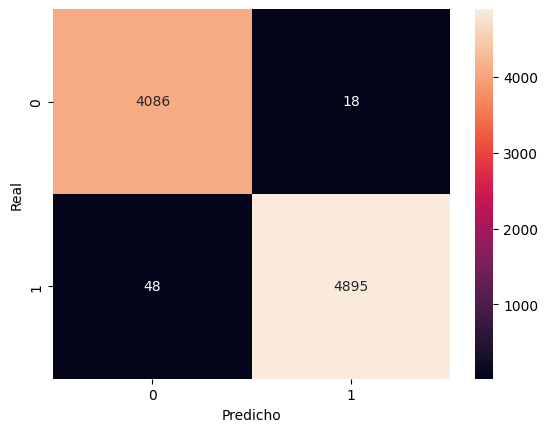

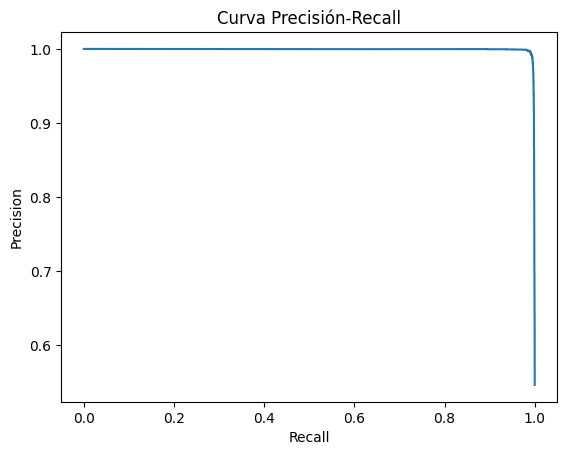

In [56]:
from sklearn.metrics import confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns


y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precisión-Recall')
plt.show()

In [6]:
import joblib

import pandas as pd
#joblib.dump(best_model, 'model.pkl')


loaded_model = joblib.load('model.pkl')


def predict_if_same_name(name1, name2, model=loaded_model, threshold=0.85):
    features = advanced_features(name1, name2)
    features_df = pd.DataFrame([features])
    
    features_df = features_df[X_train.columns]
    
    proba = model.predict_proba(features_df)[0][1]
    prediction = int(proba >= threshold)
    
    return {
        'prediction': prediction,
        'probability': proba,
        'features': features
    }


predict_if_same_name("Carlos Ruiz", "C. Ruiz")

NameError: name 'X_train' is not defined

In [1]:
name1="Danilo S Carvalho'"
name2="𝑎𝑏"
features = advanced_features(name1, name2)
features_df = pd.DataFrame([features])
proba = best_model.predict_proba(features_df)
prediction = best_model.predict(features_df)
    



NameError: name 'advanced_features' is not defined

In [129]:
proba

array([[0.02821328, 0.97178672]])

In [130]:
prediction

array([1])

In [21]:
df1.columns

Index(['id', 'doi', 'title', 'display_name', 'publication_year',
       'publication_date', 'ids', 'language', 'primary_location', 'type',
       'type_crossref', 'indexed_in', 'open_access', 'authorships',
       'institution_assertions', 'countries_distinct_count',
       'institutions_distinct_count', 'corresponding_author_ids',
       'corresponding_institution_ids', 'apc_list', 'apc_paid', 'fwci',
       'has_fulltext', 'cited_by_count', 'citation_normalized_percentile',
       'cited_by_percentile_year', 'biblio', 'is_retracted', 'is_paratext',
       'primary_topic', 'topics', 'keywords', 'concepts', 'mesh',
       'locations_count', 'locations', 'best_oa_location',
       'sustainable_development_goals', 'grants', 'datasets', 'versions',
       'referenced_works_count', 'referenced_works', 'related_works',
       'abstract_inverted_index', 'abstract_inverted_index_v3',
       'cited_by_api_url', 'counts_by_year', 'updated_date', 'created_date',
       'fulltext_origin'],
      

In [25]:
df1

,id,doi,title,display_name,publication_year,publication_date,ids,language,primary_location,type,...,referenced_works_count,referenced_works,related_works,abstract_inverted_index,abstract_inverted_index_v3,cited_by_api_url,counts_by_year,updated_date,created_date,fulltext_origin
0,https://openalex.org/W3024750580,https://doi.org/10.1021/acsomega.0c01818,Therapeutic Potential of Quercetin: New Insigh...,Therapeutic Potential of Quercetin: New Insigh...,2020,2020-05-14,{'openalex': 'https://openalex.org/W3024750580...,en,"{'is_oa': True, 'landing_page_url': 'https://d...",article,...,289,"[https://openalex.org/W1148393218, https://ope...","[https://openalex.org/W2544268735, https://ope...","{'Quercetin': [0], '(Que)': [1], 'and': [2, 21...",NaN,https://api.openalex.org/works?filter=cites:W3...,"[{'year': 2025, 'cited_by_count': 59}, {'year'...",2025-07-14T15:47:09.804269,2020-05-21,NaN
1,https://openalex.org/W2027550597,https://doi.org/10.1016/s0032-3861(00)00713-8,An infrared investigation in relation with chi...,An infrared investigation in relation with chi...,2001,2001-04-01,{'openalex': 'https://openalex.org/W2027550597...,en,"{'is_oa': False, 'landing_page_url': 'https://...",article,...,24,"[https://openalex.org/W1828500240, https://ope...","[https://openalex.org/W4293339595, https://ope...",None,NaN,https://api.openalex.org/works?filter=cites:W2...,"[{'year': 2025, 'cited_by_count': 34}, {'year'...",2025-06-23T22:13:47.718901,2016-06-24,NaN
2,https://openalex.org/W2156568771,https://doi.org/10.1371/journal.pone.0013969,Caribbean Corals in Crisis: Record Thermal Str...,Caribbean Corals in Crisis: Record Thermal Str...,2010,2010-11-15,{'openalex': 'https://openalex.org/W2156568771...,en,"{'is_oa': True, 'landing_page_url': 'https://d...",article,...,47,"[https://openalex.org/W1546452615, https://ope...","[https://openalex.org/W4386018793, https://ope...","{'Background': [0], 'The': [1, 152], 'rising':...",NaN,https://api.openalex.org/works?filter=cites:W2...,"[{'year': 2025, 'cited_by_count': 17}, {'year'...",2025-07-14T20:42:34.354798,2016-06-24,pdf
3,https://openalex.org/W2983201012,https://doi.org/10.1038/s41598-019-52748-8,Contrasting Computational Models of Mate Prefe...,Contrasting Computational Models of Mate Prefe...,2019,2019-11-15,{'openalex': 'https://openalex.org/W2983201012...,en,"{'is_oa': True, 'landing_page_url': 'https://d...",article,...,38,"[https://openalex.org/W1668408473, https://ope...","[https://openalex.org/W4245684404, https://ope...","{'Abstract': [0], 'Humans': [1], 'express': [2...",NaN,https://api.openalex.org/works?filter=cites:W2...,"[{'year': 2025, 'cited_by_count': 3}, {'year':...",2025-06-22T10:05:50.327793,2019-11-22,pdf
4,https://openalex.org/W3202287440,https://doi.org/10.1021/acs.jctc.1c00645,gmx_MMPBSA: A New Tool to Perform End-State Fr...,gmx_MMPBSA: A New Tool to Perform End-State Fr...,2021,2021-09-29,{'openalex': 'https://openalex.org/W3202287440...,en,"{'is_oa': False, 'landing_page_url': 'https://...",article,...,59,"[https://openalex.org/W1031578623, https://ope...","[https://openalex.org/W4391375266, https://ope...","{'Molecular': [0], 'mechanics/Poisson–Boltzman...",NaN,https://api.openalex.org/works?filter=cites:W3...,"[{'year': 2025, 'cited_by_count': 334}, {'year...",2025-06-18T08:45:51.121870,2021-10-11,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18721,https://openalex.org/W3092374876,None,Fenotipos de los morfos de color y bandas de l...,Fenotipos de los morfos de color y bandas de l...,1989,1989-01-01,{'openalex': 'https://openalex.org/W3092374876...,es,"{'is_oa': False, 'landing_page_url': 'https://...",article,...,0,[],[],None,NaN,https://api.openalex.org/works?filter=cites:W3...,[],2025-02-03T05:24:40.943206,2020-10-15,NaN
18722,https://openalex.org/W3080299399,None,Generacion de hibridomas secretores de anticue...,Generacion de hibridomas secretores de anticue...,1993,1993-01-01,{'openalex': 'https://openalex.org/W308

In [19]:
df1.keywords[2]

[{'id': 'https://openalex.org/keywords/coral-bleaching',
  'display_name': 'Coral bleaching',
  'score': 0.85539865},
 {'id': 'https://openalex.org/keywords/anthozoa',
  'display_name': 'Anthozoa',
  'score': 0.48954687},
 {'id': 'https://openalex.org/keywords/caribbean-region',
  'display_name': 'Caribbean region',
  'score': 0.4601617}]

In [24]:
df1.primary_topic[2]

{'id': 'https://openalex.org/T10341',
 'display_name': 'Coral and Marine Ecosystems Studies',
 'score': 1.0,
 'subfield': {'id': 'https://openalex.org/subfields/2303',
  'display_name': 'Ecology'},
 'field': {'id': 'https://openalex.org/fields/23',
  'display_name': 'Environmental Science'},
 'domain': {'id': 'https://openalex.org/domains/3',
  'display_name': 'Physical Sciences'}}

In [47]:
from collections import defaultdict
dataset = defaultdict(list)
for _,row in df1.iterrows():
    if row['primary_topic']:
        tema = row['primary_topic']['field']['display_name']
        a=[]
        for key in row['keywords']:
            s= key['display_name']
            a.append(s)
        dataset[tema].extend(a)

In [51]:
len(dataset.keys())

26

In [52]:
dataset.keys()

dict_keys(['Medicine', 'Materials Science', 'Environmental Science', 'Psychology', 'Physics and Astronomy', 'Chemistry', 'Social Sciences', 'Energy', 'Neuroscience', 'Agricultural and Biological Sciences', 'Engineering', 'Computer Science', 'Biochemistry, Genetics and Molecular Biology', 'Pharmacology, Toxicology and Pharmaceutics', 'Health Professions', 'Earth and Planetary Sciences', 'Economics, Econometrics and Finance', 'Chemical Engineering', 'Nursing', 'Dentistry', 'Mathematics', 'Business, Management and Accounting', 'Immunology and Microbiology', 'Arts and Humanities', 'Decision Sciences', 'Veterinary'])

In [53]:
dataset

defaultdict(list,
            {'Medicine': ['Health Benefits',
              'Cross-sectional study',
              'Glycoconjugate',
              'Conjugate',
              'Bacterial capsule',
              'Verbal autopsy',
              'Biostatistics',
              'Cognitive reserve',
              'Middle income country',
              'Sponge',
              'Biocompatibility',
              'Clotting time',
              'Mangiferin',
              'Mangifera',
              'Ozone Therapy',
              'Ozone Therapy',
              'Pomace',
              'Vero cell',
              'Cross-sectional study',
              'Tricin',
              'Saccharum officinarum',
              'Flavones',
              'Phenolic acid',
              'Cane',
              'Sugar cane',
              'Hydroxycinnamic acid',
              'Ozone Therapy',
              'Differential item functioning',
              'Measurement Invariance',
              'Factor Analysis',
            

In [1]:
import pandas as pd

In [6]:
df2 = pd.read_json("data/extract_result.json")

In [10]:
df2 = df2.T 

In [13]:
a=[]
for i in df2['keywords']:
    for j in i:
        a.append(j)

In [14]:
a

['cosmology',
 'observations -cosmology',
 'dark energy -supernovae',
 'general',
 'public transport',
 'accessibility',
 'network science',
 'metro network',
 'equity',
 'Ambient Intelligence',
 'Physical Rehabilitation',
 'Vision Language Models',
 'AI framework',
 '3D Reconstruction',
 'malware detection',
 'concept drift',
 'semisupervised learning',
 'pseudo-labeling',
 'Age of information',
 'laser-powered UAV systems',
 'multi-agent reinforcement learning',
 'and IoT data collection',
 'misspecification',
 'identifiability',
 'Gaussian processes',
 'logistic growth',
 'inference',
 'Cloud computing',
 'Variable sized-quantum neural network',
 'Comprehensive architectural optimization',
 'Resource',
 'Argument mining',
 'Transformers',
 'Large Language Models',
 'Cognitive intelligence',
 'NLP',
 'Scaled relative graphs',
 'Stability theory',
 'switching controllers',
 'linear matrix inequalities',
 'End-to-end document transcription',
 'learnable symbol assembly',
 'engineering 

In [4]:
import requests
import time
from urllib.parse import quote

def classify_keywords_openalex(keywords):
    """
    Clasifica una lista de palabras clave utilizando la API de OpenAlex para encontrar
    sus campos de estudio y dominios de nivel superior.

    Args:
        keywords (list): Una lista de strings con las palabras clave a clasificar.

    Returns:
        dict: Un diccionario donde cada clave es la palabra clave original y su valor
              es otro diccionario con 'dominio', 'campo' y 'concepto_encontrado'.
    """
    base_url = "https://api.openalex.org/concepts"
    headers = {
        'User-Agent': 'python-requests/2.28.1 (mailto:tu_email@ejemplo.com)'
    }
    
    classifications = {}

    print("Consultando la base de datos de OpenAlex...")
    for keyword in keywords:
        encoded_keyword = quote(keyword)
        url = f"{base_url}?filter=display_name.search:{encoded_keyword}"

        try:
            response = requests.get(url, headers=headers, timeout=10)
            response.raise_for_status()
            
            data = response.json()

            if data['results']:
                top_result = data['results'][0]
                concept_name = top_result.get('display_name', 'N/A')

                ancestors = top_result.get('ancestors', [])

                domain = next((anc['display_name'] for anc in ancestors if anc['level'] == 0), "No encontrado")

                field = next((anc['display_name'] for anc in ancestors if anc['level'] == 1), "No encontrado")
                
                classifications[keyword] = {
                    "concepto_encontrado": concept_name,
                    "dominio_principal": domain,
                    "campo": field,
                }
            else:
                classifications[keyword] = {
                    "concepto_encontrado": "No encontrado",
                    "dominio_principal": "No encontrado",
                    "campo": "No encontrado",
                }

        except requests.exceptions.RequestException as e:
            print(f"Error al procesar '{keyword}': {e}")
            classifications[keyword] = {
                "concepto_encontrado": f"Error: {e}",
                "dominio_principal": "Error",
                "campo": "Error",
            }
        
        time.sleep(0.5)

    return classifications

keywords_a_clasificar = ["Cognitive intelligence", "gender equality", "renewable energy", "oceanography", "quantum computing"]

resultados = classify_keywords_openalex(keywords_a_clasificar)

print("\n--- Resultados de Clasificación ---")
for kw, classification in resultados.items():
    print(f"\nPalabra clave: '{kw}'")
    print(f"  -> Concepto más cercano: '{classification['concepto_encontrado']}'")
    print(f"  -> Dominio Principal:     '{classification['dominio_principal']}'")
    print(f"  -> Campo de estudio:      '{classification['campo']}'")


Consultando la base de datos de OpenAlex...

--- Resultados de Clasificación ---

Palabra clave: 'Cognitive intelligence'
  -> Concepto más cercano: 'No encontrado'
  -> Dominio Principal:     'No encontrado'
  -> Campo de estudio:      'No encontrado'

Palabra clave: 'gender equality'
  -> Concepto más cercano: 'Gender equality'
  -> Dominio Principal:     'Sociology'
  -> Campo de estudio:      'Gender studies'

Palabra clave: 'renewable energy'
  -> Concepto más cercano: 'Renewable energy'
  -> Dominio Principal:     'Biology'
  -> Campo de estudio:      'Ecology'

Palabra clave: 'oceanography'
  -> Concepto más cercano: 'Oceanography'
  -> Dominio Principal:     'Geology'
  -> Campo de estudio:      'No encontrado'

Palabra clave: 'quantum computing'
  -> Concepto más cercano: 'Superconducting quantum computing'
  -> Dominio Principal:     'Physics'
  -> Campo de estudio:      'Condensed matter physics'
